# Image Processing: Face Recognition and Evolution

## Setup Code

In [2]:
#import libraries

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.layers import Reshape, Conv2DTranspose, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D

## Parse Data

In [3]:
data_path = "UTKFace"
files = os.listdir(data_path)

data = []

for file in files:
    try:
        age, gender, race, date = file.split('_')
        age, gender, race = int(age), int(gender), int(race)
        img_bgr = cv2.imread(os.path.join(data_path, file))
        #resize image to 64x64
        img_bgr = cv2.resize(img_bgr, (64, 64))
        
        # Convert to RGB (for CNN)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Convert to grayscale (for PCA)
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        
        data.append([img_rgb, img_gray, age, gender, race])
        
    except Exception as e:
        print(f"Skipping {file}: {e}")
        continue
    
df = pd.DataFrame(data, columns=["rgb_image", "gray_image", "age", "gender", "race"])

print(df.shape)
df.head()
        

Skipping 39_1_20170116174525125.jpg.chip.jpg: not enough values to unpack (expected 4, got 3)
Skipping 61_1_20170109150557335.jpg.chip.jpg: not enough values to unpack (expected 4, got 3)
Skipping 61_1_20170109142408075.jpg.chip.jpg: not enough values to unpack (expected 4, got 3)
(23705, 5)


,rgb_image,gray_image,age,gender,race
0,"[[[90, 104, 71], [80, 93, 63], [82, 93, 64], [...","[[96, 86, 86, 101, 102, 84, 58, 46, 25, 19, 21...",9,1,2
1,"[[[240, 224, 39], [238, 219, 40], [230, 205, 3...","[[208, 204, 193, 192, 177, 168, 160, 145, 116,...",36,0,1
2,"[[[222, 227, 207], [221, 228, 210], [219, 226,...","[[223, 224, 222, 207, 220, 220, 212, 229, 226,...",86,1,0
3,"[[[239, 238, 252], [239, 238, 252], [239, 238,...","[[240, 240, 240, 240, 240, 240, 240, 240, 240,...",26,1,0
4,"[[[94, 60, 48], [90, 57, 42], [110, 77, 60], [...","[[69, 65, 85, 105, 123, 144, 161, 170, 171, 16...",1,1,2


## Dataset Sample Statistics

In [ ]:
#Gender and Race Bar Chart
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='gender', data=df, ax=ax[0])
ax[0].set_title('Gender Distribution (0=Male, 1=Female)')
sns.countplot(x='race', data=df, ax=ax[1])
ax[1].set_title('Race Distribution (0=White, 1=Black, 2=Asian, 3=Indian, 4=Other)')
plt.show()

In [ ]:
#age frequency
df[['age']].describe()

In [ ]:
#age histogram
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=False)
plt.title('Age Distribution in UTKFace Dataset')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#z-score of age
df['age_zscore'] = zscore(df['age'])
sns.histplot(df['age_zscore'], bins=30, kde=True)
plt.title('Z-Score Distribution of Age')
plt.xlabel('Z-Score')
plt.ylabel('Count')
plt.show()

In [ ]:
#age and gender boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='age', data=df)
plt.title('Age Distribution by Gender')
plt.xlabel('Gender (0=Male, 1=Female)')
plt.ylabel('Age')
plt.show()

#age and race boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='race', y='age', data=df)
plt.title('Age Distribution by Race')
plt.xlabel('Race (0=White, 1=Black, 2=Asian, 3=Indian, 4=Other)')
plt.ylabel('Age')
plt.show()

## Eigenfaces(PCA)
## _____________________________________________________________

In [4]:
#flatten grayscale images for PCA
X_pca = np.array(df["gray_image"].tolist())
X_pca = X_pca.reshape(len(X_pca), -1)
print("X_pca Shape:", X_pca.shape)

pca_eigenfaces = PCA(n_components=100, svd_solver='randomized')
pca_eigenfaces.fit(X_pca)

eigenfaces = pca_eigenfaces.components_.reshape((100, 64, 64))
print("Eigenfaces shape:", eigenfaces.shape)

X_pca Shape: (23705, 4096)
Eigenfaces shape: (100, 64, 64)


In [ ]:
# Time to visualize some eigenfaces

plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(eigenfaces[i], cmap='gray')
    plt.title(f'Eigenface {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#Reconstruction part (still under Eigenfaces)
idx = 6  #I just chose image 7; can be changed 
original = X_pca[idx]
 
predicted = pca_eigenfaces.transform(original.reshape(1, -1))
reconstructed = pca_eigenfaces.inverse_transform(predicted).reshape(64, 64)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(original.reshape(64, 64), cmap='gray')
plt.title('Original')
plt.axis('off')
plt.show()

## PCA Gender Classification

In [5]:
pca = PCA(n_components= 200, svd_solver='randomized')

# the percentage of test images where predicted_gender == true_gender
X_train_pca_gender, X_test_pca_gender, y_train_pca_gender, y_test_pca_gender = train_test_split(X_pca, df['gender'], test_size=0.2)
X_train_pg = pca.fit_transform(X_train_pca_gender)
X_test_pg = pca.transform(X_test_pca_gender)  

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pg, y_train_pca_gender)

accuracy = knn.score(X_test_pg, y_test_pca_gender)

print("knn accuracy:", accuracy)

knn accuracy: 0.7418266188567813


In [35]:
pca_gender_model = LogisticRegression(max_iter=2000)
pca_gender_model.fit(X_train_pg, y_train_pca_gender)

prediction = pca_gender_model.predict_proba(X_test_pg)

print("confidence between male vs female", prediction[1])
print("Actual gender label:", y_test_pca_gender.iloc[1])

confidence between male vs female [0.77375462 0.22624538]
Actual gender label: 1


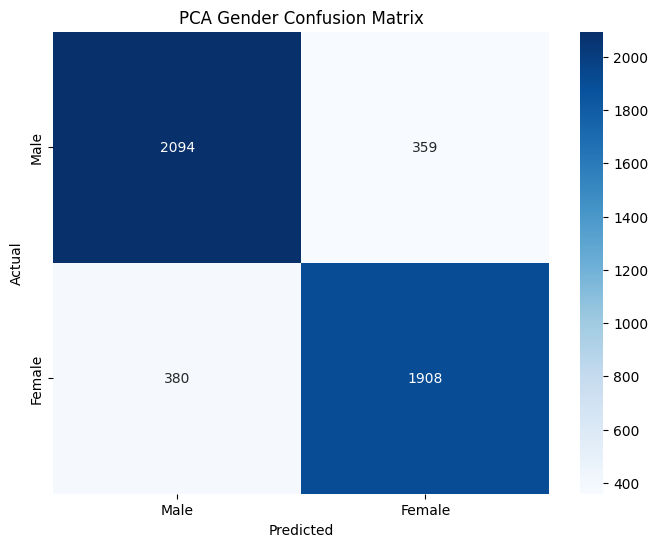

              precision    recall  f1-score   support

           0     0.8464    0.8536    0.8500      2453
           1     0.8416    0.8339    0.8378      2288

    accuracy                         0.8441      4741
   macro avg     0.8440    0.8438    0.8439      4741
weighted avg     0.8441    0.8441    0.8441      4741



In [7]:
#PCA Gender Confusion Matrix

# Predicted labels
y_pred_pca_gender = (pca_gender_model.predict(X_test_pg) > 0.5).astype('int32')
#y_pred_pca_gender = knn.predict(X_test_pg)

# Confusion matrix
matrix_gender_pca = confusion_matrix(y_test_pca_gender, y_pred_pca_gender)

# Visualization
plt.figure(figsize=(8,6))
sns.heatmap(matrix_gender_pca, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Male','Female'], yticklabels=['Male','Female'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PCA Gender Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_test_pca_gender, y_pred_pca_gender, digits=4))

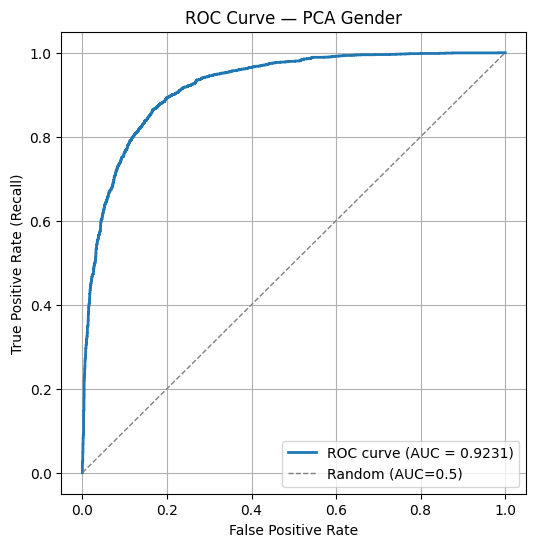

In [8]:
#ROC-AUC Curve
from sklearn.metrics import roc_curve, auc

# predicted probability for class 1 (female)
probs = pca_gender_model.predict_proba(X_test_pg)[:, 1]

# compute ROC
fpr, tpr, thresholds = roc_curve(y_test_pca_gender, probs)
roc_auc = auc(fpr, tpr)

# plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='C0', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — PCA Gender')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## PCA Race Classification

In [9]:

X_train_pca_race, X_test_pca_race, y_train_pca_race, y_test_pca_race = train_test_split(
    X_pca, df['race'], test_size=0.2, random_state=42
)

X_train_pr = pca.fit_transform(X_train_pca_race)
X_test_pr = pca.transform(X_test_pca_race)

knn_race = KNeighborsClassifier(n_neighbors=5)
knn_race.fit(X_train_pr, y_train_pca_race)

accuracy_race_knn = knn_race.score(X_test_pr, y_test_pca_race)
print("KNN Race Accuracy:", accuracy_race_knn)

KNN Race Accuracy: 0.5351191731702173


In [10]:

race_classes = np.unique(y_train_pca_race)
race_weights = compute_class_weight(class_weight='balanced', classes=race_classes, y=y_train_pca_race)
class_weight_dict_pca = {cls: weight for cls, weight in zip(race_classes, race_weights)}
print("Race class weights:", class_weight_dict_pca)

pca_race_model = LogisticRegression(
    max_iter=7000,
    multi_class='multinomial',
    solver='lbfgs',
    class_weight=class_weight_dict_pca
)

pca_race_model.fit(X_train_pr, y_train_pca_race)


prediction_race_pca = pca_race_model.predict_proba(X_test_pr)

print("confidence between races", prediction_race_pca[2])
print("Actual race label:", y_test_pca_race.iloc[2])

Race class weights: {np.int64(0): np.float64(0.47321272613849036), np.int64(1): np.float64(1.036850738108256), np.int64(2): np.float64(1.3742028985507246), np.int64(3): np.float64(1.188220551378446), np.int64(4): np.float64(2.8325616131441373)}


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


confidence between races [0.20092114 0.0052526  0.00223357 0.09572787 0.69586482]
Actual race label: 4


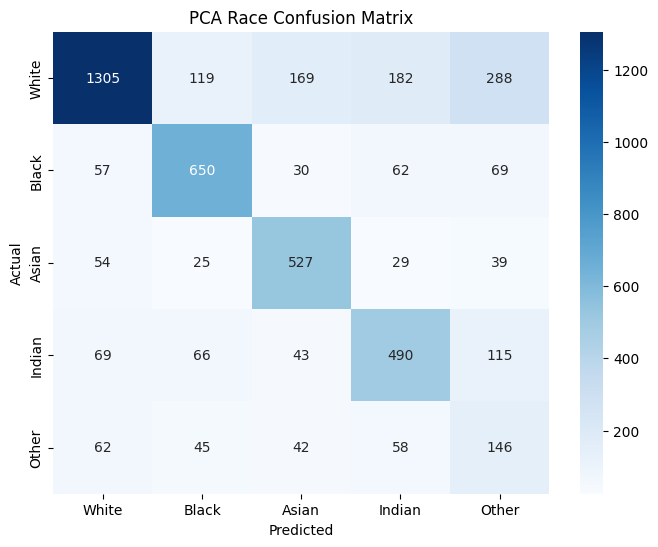

              precision    recall  f1-score   support

           0     0.8436    0.6326    0.7230      2063
           1     0.7182    0.7488    0.7332       868
           2     0.6498    0.7819    0.7098       674
           3     0.5968    0.6258    0.6110       783
           4     0.2222    0.4136    0.2891       353

    accuracy                         0.6577      4741
   macro avg     0.6061    0.6405    0.6132      4741
weighted avg     0.7061    0.6577    0.6722      4741



In [11]:
# Predicted labels
y_pred_race_pca = pca_race_model.predict(X_test_pr)

# Confusion matrix
matrix_race_pca = confusion_matrix(y_test_pca_race, y_pred_race_pca)

# Visualization
plt.figure(figsize=(8,6))
sns.heatmap(matrix_race_pca, annot=True, fmt='d', cmap='Blues', xticklabels=["White", "Black", "Asian", "Indian", "Other"], yticklabels=["White", "Black", "Asian", "Indian", "Other"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PCA Race Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_test_pca_race, y_pred_race_pca, digits=4))

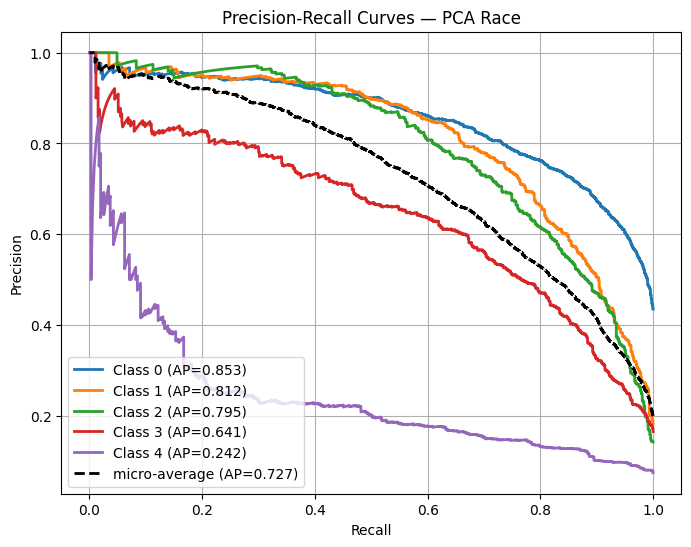

In [12]:
#Precision Recall Curve

y_true = np.array(y_test_pca_race)

# Binarize true labels for one-vs-rest PR computation
y_true_bin = label_binarize(y_true, classes=race_classes)

# Compute precision-recall for each class
plt.figure(figsize=(8,6))
average_precision = {}
for i, cls in enumerate(race_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], prediction_race_pca[:, i])
    ap = average_precision_score(y_true_bin[:, i], prediction_race_pca[:, i])
    average_precision[i] = ap
    plt.plot(recall, precision, lw=2, label=f'Class {cls} (AP={ap:.3f})')

# Compute micro-average precision-recall
precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), prediction_race_pca.ravel())
ap_micro = average_precision_score(y_true_bin, prediction_race_pca, average='micro')
plt.plot(recall_micro, precision_micro, color='k', lw=2, linestyle='--', label=f'micro-average (AP={ap_micro:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — PCA Race')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

## PCA Age Classification

In [13]:
X_train_pca_age, X_test_pca_age, y_train_pca_age, y_test_pca_age = train_test_split(
    X_pca, df['age'], test_size=0.2, random_state=42
)

X_train_pa = pca.fit_transform(X_train_pca_age)
X_test_pa = pca.transform(X_test_pca_age)

knn_age = KNeighborsRegressor(n_neighbors=5)
knn_age.fit(X_train_pa, y_train_pca_age)

y_pred_age_knn = knn_age.predict(X_test_pa)

mae_pca_age_knn = mean_absolute_error(y_test_pca_age, y_pred_age_knn)
mse_pca_age_knn = mean_squared_error(y_test_pca_age, y_pred_age_knn)

print("PCA + KNN Age MAE:", mae_pca_age_knn)
print("PCA + KNN Age MSE:", mse_pca_age_knn)

PCA + KNN Age MAE: 12.451465935456655
PCA + KNN Age MSE: 283.5392701961611


In [14]:
pca_age_model = LinearRegression()
pca_age_model.fit(X_train_pa, y_train_pca_age)

y_pred_age_pca = pca_age_model.predict(X_test_pa)

mae_pca_age = mean_absolute_error(y_test_pca_age, y_pred_age_pca)
mse_pca_age = mean_squared_error(y_test_pca_age, y_pred_age_pca)

print("PCA Age MAE:", mae_pca_age)
print("PCA Age MSE:", mse_pca_age)

print("Predicted age:", y_pred_age_pca[6])
print("Actual age:", y_test_pca_age.iloc[6])

PCA Age MAE: 11.411011985600513
PCA Age MSE: 222.67465577167977
Predicted age: 62.050801734583125
Actual age: 54


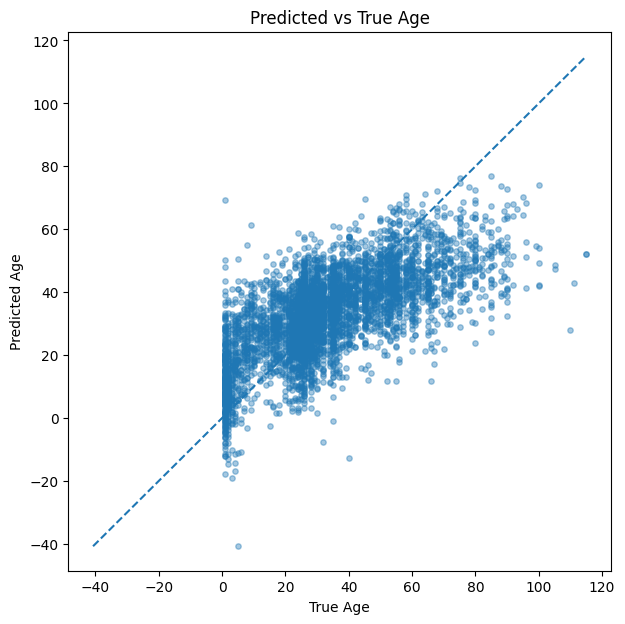

In [15]:
#Predicted age vs Actual age plot

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_pca_age,
    y_pred_age_pca,
    alpha=0.4,
    s=15
)

# Ideal prediction line
min_age = min(y_test_pca_age.min(), y_pred_age_pca.min())
max_age = max(y_test_pca_age.max(), y_pred_age_pca.max())
plt.plot([min_age, max_age], [min_age, max_age], linestyle='--')

plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs True Age")

plt.show()

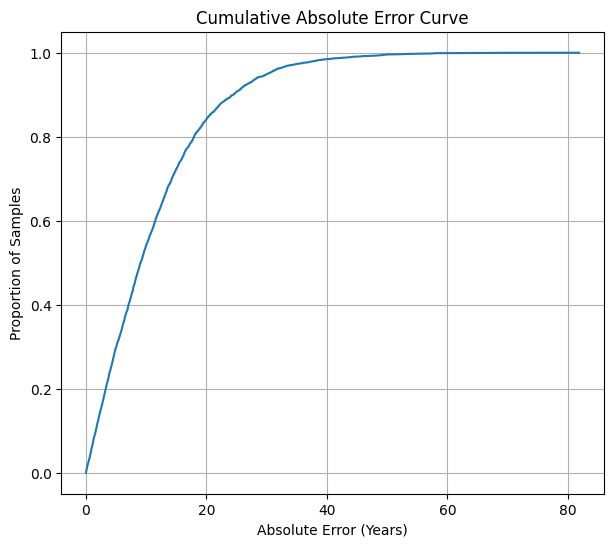

In [16]:
# Absolute errors
abs_errors = np.abs(y_pred_age_pca - y_test_pca_age)

# Sort errors
sorted_errors = np.sort(abs_errors)

# Cumulative proportion
cummulative_frac = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

plt.figure(figsize=(7, 6))

plt.plot(sorted_errors, cummulative_frac)

plt.xlabel("Absolute Error (Years)")
plt.ylabel("Proportion of Samples")
plt.title("Cumulative Absolute Error Curve")

plt.grid(True)
plt.show()

## Convolution Neural Network (CNN)
## _____________________________________________________________

## CNN Gender Classficiation

In [17]:
X_cnn = np.array(df['rgb_image'].tolist()) / 255.0
y_gender = df['gender']

X_train_cnn_gender, X_test_cnn_gender, y_train_cnn_gender, y_test_cnn_gender = train_test_split(X_cnn, y_gender, test_size=0.2, stratify = y_gender)

In [18]:
#Model
cnn_gender_model = Sequential()
cnn_gender_model.add(Input(shape=(64, 64, 3)))

cnn_gender_model.add(Conv2D(32, (3,3), activation='relu'))
cnn_gender_model.add(MaxPooling2D((2,2)))

cnn_gender_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_gender_model.add(MaxPooling2D((2,2)))

cnn_gender_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_gender_model.add(MaxPooling2D((2,2)))

cnn_gender_model.add(Flatten())
cnn_gender_model.add(Dense(128, activation='relu'))
cnn_gender_model.add(Dropout(0.3))
cnn_gender_model.add(Dense(1, activation='sigmoid'))


cnn_gender_model.compile(
   optimizer = 'adam',
   loss = 'binary_crossentropy',
   metrics = ['accuracy']
)

cnn_gender_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# start doing some training 
training_model = cnn_gender_model.fit(X_train_cnn_gender, y_train_cnn_gender, validation_split= 0.2, epochs = 15, batch_size= 64)

Epoch 1/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.7514 - loss: 0.4992 - val_accuracy: 0.8260 - val_loss: 0.4109
Epoch 2/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.8554 - loss: 0.3290 - val_accuracy: 0.8576 - val_loss: 0.3133
Epoch 3/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.8719 - loss: 0.2901 - val_accuracy: 0.8785 - val_loss: 0.2832
Epoch 4/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.8841 - loss: 0.2601 - val_accuracy: 0.8824 - val_loss: 0.2647
Epoch 5/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.8985 - loss: 0.2378 - val_accuracy: 0.8861 - val_loss: 0.2698
Epoch 6/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.9087 - loss: 0.2219 - val_accuracy: 0.8814 - val_loss: 0.2680
Epoch 7/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.9121 - loss: 0.2064 - val_accuracy: 0.8866 - val_loss: 0.2788
Epoch 8/15
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.9171 - loss: 0.1918 - 

In [21]:
# Evaluate CNN accuracy (Should be much better than Eigenfaces I think)
test_loss_cnn_gender, test_acc_cnn_gender = cnn_gender_model.evaluate(X_test_cnn_gender, y_test_cnn_gender)
print("Test accuracy:", test_acc_cnn_gender)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8920 - loss: 0.3635
Test accuracy: 0.8920059204101562


149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


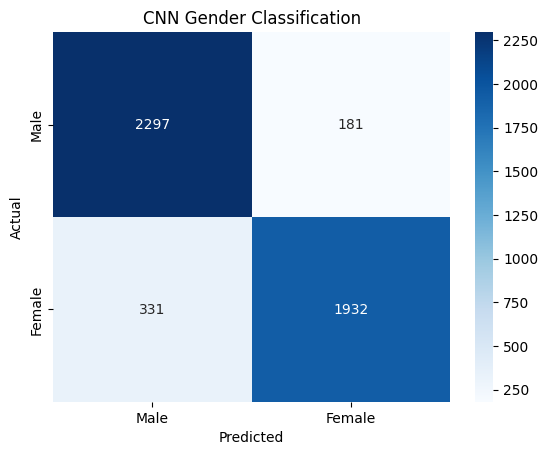

              precision    recall  f1-score   support

           0     0.8740    0.9270    0.8997      2478
           1     0.9143    0.8537    0.8830      2263

    accuracy                         0.8920      4741
   macro avg     0.8942    0.8903    0.8914      4741
weighted avg     0.8933    0.8920    0.8917      4741

Actual males predicted: 2297
Misclassified males: 181
Actual females predicted: 1932
Misclassified females: 331

 Total correct predictions: 4229 / 4741
Accuracy: 0.89


In [22]:
#Create confusion matrix
y_pred_cnn_gender = (cnn_gender_model.predict(X_test_cnn_gender) > 0.5).astype('int32')
cnn_gender_matrix = confusion_matrix(y_test_cnn_gender, y_pred_cnn_gender)

sns.heatmap(cnn_gender_matrix, annot = True, fmt = 'd', cmap = 'Blues', xticklabels=['Male', 'Female'], yticklabels= ['Male', 'Female'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Gender Classification")
plt.show()

actual_male_predicted = cnn_gender_matrix[0][0]
misclassified_male = cnn_gender_matrix[0][1]
actual_female_predicted = cnn_gender_matrix[1][1]
misclassified_female = cnn_gender_matrix[1][0]

total_correct = actual_male_predicted + actual_female_predicted
total_image = cnn_gender_matrix.sum()

print(classification_report(y_test_cnn_gender, y_pred_cnn_gender, digits=4))

print(f"Actual males predicted: {actual_male_predicted}")
print(f"Misclassified males: {misclassified_male}")
print(f"Actual females predicted: {actual_female_predicted}")
print(f"Misclassified females: {misclassified_female}")

print(f"\n Total correct predictions: {total_correct} / {total_image}")
print(f"Accuracy: {total_correct / total_image:.2f}")




149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


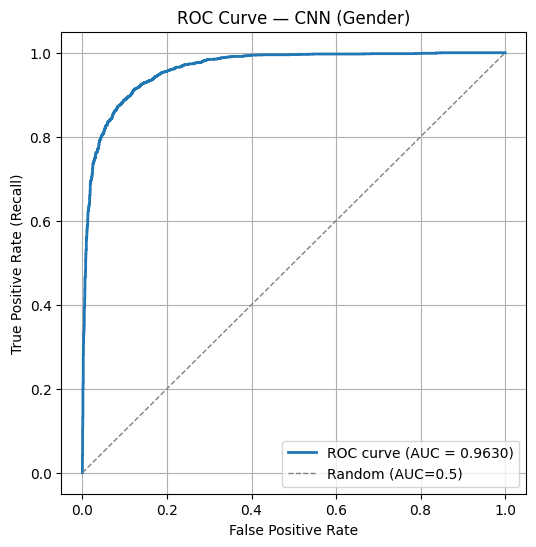

In [23]:
# predicted probability for class 1 (female)
probs_cnn_gender = cnn_gender_model.predict(X_test_cnn_gender).ravel()

# compute ROC
fpr_cnn_gender, tpr_cnn_gender, thresholds_cnn_gender = roc_curve(y_test_cnn_gender, probs_cnn_gender)
roc_auc_cnn_gender = auc(fpr_cnn_gender, tpr_cnn_gender)

# plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr_cnn_gender, tpr_cnn_gender, color='C0', lw=2, label=f'ROC curve (AUC = {roc_auc_cnn_gender:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — CNN (Gender)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## CNN Race Classification

In [24]:
y_race = df['race']

race_classes = np.unique(y_race)
race_class_weights = compute_class_weight(class_weight='balanced', classes=race_classes, y=y_race)

class_weight_dict = {cls: weight for cls, weight in zip(race_classes, race_class_weights)}
print("Race class weights:", class_weight_dict)

Race class weights: {np.int64(0): np.float64(0.47043064100019844), np.int64(1): np.float64(1.0475033141847105), np.int64(2): np.float64(1.3806057076295866), np.int64(3): np.float64(1.1927044025157232), np.int64(4): np.float64(2.8020094562647753)}


In [25]:

X_train_cnn_race, X_test_cnn_race, y_train_cnn_race, y_test_cnn_race = train_test_split(
    X_cnn, y_race, test_size=0.2, stratify=y_race, random_state=42
)

cnn_race_model = Sequential()
cnn_race_model.add(Input(shape=(64, 64, 3)))

cnn_race_model.add(Conv2D(32, (3,3), activation='relu'))
cnn_race_model.add(MaxPooling2D((2,2)))

cnn_race_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_race_model.add(MaxPooling2D((2,2)))

cnn_race_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_race_model.add(MaxPooling2D((2,2)))

cnn_race_model.add(Flatten())
cnn_race_model.add(Dense(128, activation='relu'))
cnn_race_model.add(Dropout(0.3))

print(len(np.unique(y_race)))

cnn_race_model.add(Dense(len(np.unique(y_race)), activation='softmax'))

cnn_race_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_race_model.summary()

5


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,845 (2.61 MB)

 Trainable params: 683,845 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#train

training_model2 = cnn_race_model.fit(
    X_train_cnn_race, 
    y_train_cnn_race,
    validation_split=0.1,
    epochs=12,
    batch_size=64,
    class_weight=class_weight_dict
)

Epoch 1/12
267/267 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.4426 - loss: 1.3275 - val_accuracy: 0.6125 - val_loss: 1.0538
Epoch 2/12
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.6275 - loss: 1.0181 - val_accuracy: 0.7122 - val_loss: 0.8417
Epoch 3/12
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.6755 - loss: 0.9115 - val_accuracy: 0.6943 - val_loss: 0.8632
Epoch 4/12
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.6994 - loss: 0.8463 - val_accuracy: 0.7217 - val_loss: 0.7868
Epoch 5/12
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.7184 - loss: 0.7962 - val_accuracy: 0.7512 - val_loss: 0.7000
Epoch 6/12
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.7404 - loss: 0.7312 - val_accuracy: 0.7601 - val_loss: 0.6837
Epoch 7/12
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.7482 - loss: 0.6975 - val_accuracy: 0.7285 - val_loss: 0.7515
Epoch 8/12
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.7666 - loss: 0.6515 - 

In [27]:

test_loss_cnn_race, test_acc_cnn_race = cnn_race_model.evaluate(X_test_cnn_race, y_test_cnn_race)
print("Test accuracy:", test_acc_cnn_race)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7581 - loss: 0.6905
Test accuracy: 0.7580679059028625


149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


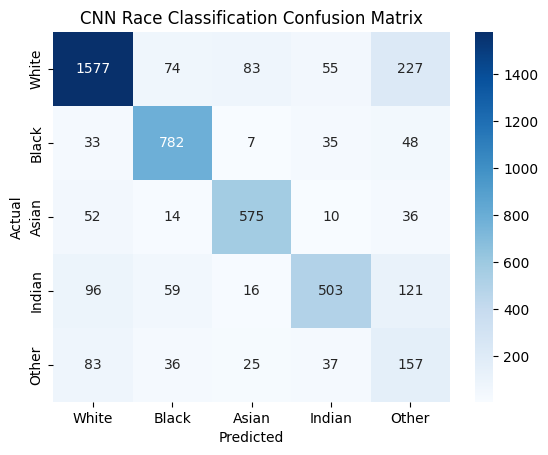

              precision    recall  f1-score   support

           0     0.8566    0.7822    0.8177      2016
           1     0.8104    0.8641    0.8364       905
           2     0.8144    0.8370    0.8256       687
           3     0.7859    0.6327    0.7010       795
           4     0.2666    0.4645    0.3387       338

    accuracy                         0.7581      4741
   macro avg     0.7068    0.7161    0.7039      4741
weighted avg     0.7878    0.7581    0.7687      4741



In [28]:
# Confusion matrix
y_pred_cnn_race = np.argmax(cnn_race_model.predict(X_test_cnn_race), axis=1)
cnn_race_matrix = confusion_matrix(y_test_cnn_race, y_pred_cnn_race)
sns.heatmap(cnn_race_matrix, annot=True, fmt='d', xticklabels= ["White", "Black", "Asian", "Indian", "Other"], yticklabels= ["White", "Black", "Asian", "Indian", "Other"], cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Race Classification Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_test_cnn_race, y_pred_cnn_race, digits=4))

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


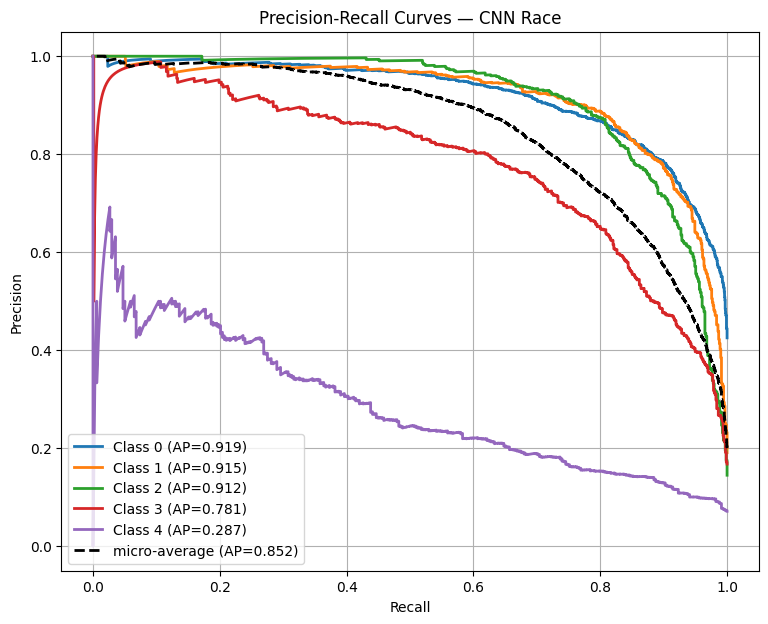

In [29]:
#Precision Recall Curve

y_true_cnn_race = np.array(y_test_cnn_race)
y_score_cnn_race = cnn_race_model.predict(X_test_cnn_race)

# Get class labels used for training/testing
cnn_race_classes = np.unique(y_train_cnn_race)

# Binarize true labels for one-vs-rest PR computation
y_true_bin_cnn_race = label_binarize(y_true_cnn_race, classes=cnn_race_classes)

# Plot per-class Precision-Recall curves and compute AP
plt.figure(figsize=(9,7))
average_precision = {}
for i, cls in enumerate(cnn_race_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin_cnn_race[:, i], y_score_cnn_race[:, i])
    ap = average_precision_score(y_true_bin_cnn_race[:, i], y_score_cnn_race[:, i])
    average_precision[i] = ap
    plt.plot(recall, precision, lw=2, label=f'Class {cls} (AP={ap:.3f})')

# Micro-average precision-recall
precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin_cnn_race.ravel(), y_score_cnn_race.ravel())
ap_micro = average_precision_score(y_true_bin_cnn_race, y_score_cnn_race, average='micro')
plt.plot(recall_micro, precision_micro, color='k', lw=2, linestyle='--', label=f'micro-average (AP={ap_micro:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — CNN Race')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

## CNN Age Classification

In [26]:
# Prepare age data
y_age = df['age']

# Split train/test
X_train_cnn_age, X_test_cnn_age, y_train_cnn_age, y_test_cnn_age = train_test_split(
    X_cnn, y_age, test_size=0.2, random_state=42
)

# Build CNN model for age regression
cnn_age_model = Sequential()
cnn_age_model.add(Input(shape=(64, 64, 3)))

cnn_age_model.add(Conv2D(32, (3,3), activation='relu'))
cnn_age_model.add(MaxPooling2D((2,2)))

cnn_age_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_age_model.add(MaxPooling2D((2,2)))

cnn_age_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_age_model.add(MaxPooling2D((2,2)))

cnn_age_model.add(Flatten())
cnn_age_model.add(Dense(128, activation='relu'))
cnn_age_model.add(Dropout(0.3))
cnn_age_model.add(Dense(1))  # Single output node for age (no activation for regression)

cnn_age_model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae']  # Mean Absolute Error
)

cnn_age_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Train
training_model3 = cnn_age_model.fit(
    X_train_cnn_age,
    y_train_cnn_age,
    validation_split=0.1,
    epochs=20,
    batch_size=64
)

Epoch 1/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - loss: 453.9843 - mae: 16.3827 - val_loss: 326.6763 - val_mae: 14.4402
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - loss: 289.6453 - mae: 13.0588 - val_loss: 198.5508 - val_mae: 10.6784
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - loss: 212.5347 - mae: 10.9714 - val_loss: 184.8152 - val_mae: 10.7767
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - loss: 174.8522 - mae: 9.9074 - val_loss: 150.0718 - val_mae: 9.2804
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - loss: 164.0052 - mae: 9.5340 - val_loss: 140.3639 - val_mae: 8.9811
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - loss: 147.3125 - mae: 9.0266 - val_loss: 129.1164 - val_mae: 8.4846
Epoch 7/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - loss: 130.1947 - mae: 8.4870 - val_loss: 126.8469 - val_mae: 8.6199
Epoch 8/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - loss: 124.8429 - mae: 8.2904 - val_loss: 123.7357 - val_mae: 8.1170
Ep

In [32]:
# Evaluate
test_loss_cnn_age, test_mae_cnn_age = cnn_age_model.evaluate(X_test_cnn_age, y_test_cnn_age)
print(f"Test MAE: {test_mae_cnn_age:.2f} years")
print(f"Test MSE: {test_loss_cnn_age:.2f}")

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 93.0309 - mae: 6.8436
Test MAE: 6.84 years
Test MSE: 93.03


149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


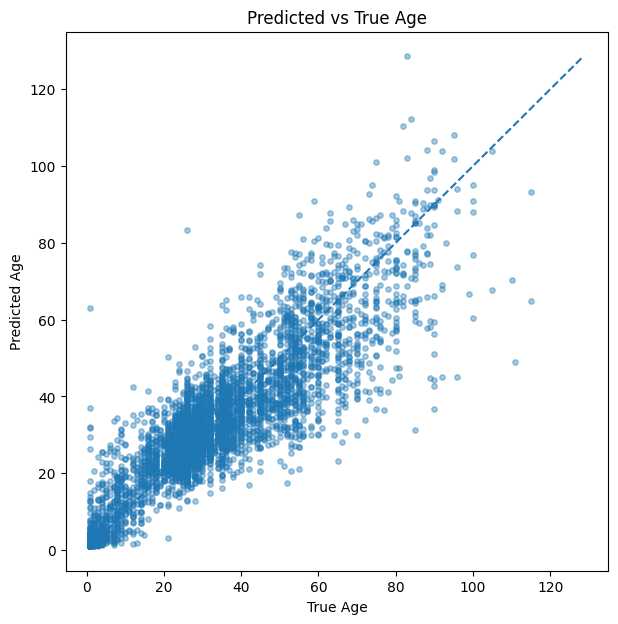

In [33]:
#Predicted age vs Actual age plot
y_pred_age_cnn = cnn_age_model.predict(X_test_cnn_age).flatten()

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_cnn_age,
    y_pred_age_cnn,
    alpha=0.4,
    s=15
)

# Ideal prediction line
min_age_cnn = min(y_test_cnn_age.min(), y_pred_age_cnn.min())
max_age_cnn = max(y_test_cnn_age.max(), y_pred_age_cnn.max())
plt.plot([min_age_cnn, max_age_cnn], [min_age_cnn, max_age_cnn], linestyle='--')

plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs True Age")

plt.show()

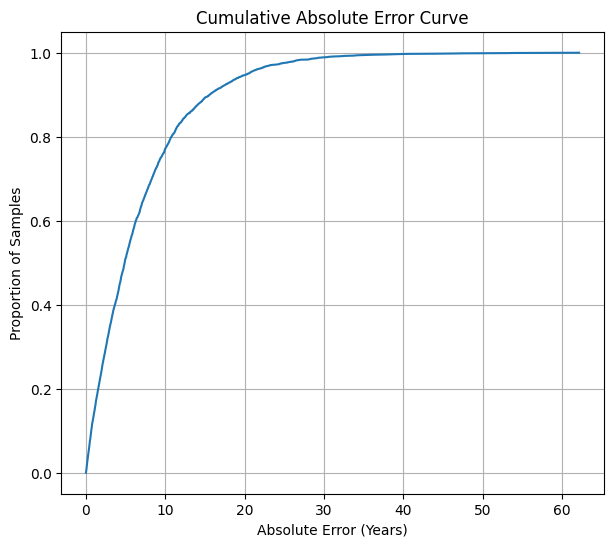

In [34]:
# Absolute errors
abs_errors_cnn = np.abs(y_pred_age_cnn - y_test_cnn_age)

# Sort errors
sorted_errors_cnn = np.sort(abs_errors_cnn)

# Cumulative proportion
cummulative_frac_cnn = np.arange(1, len(sorted_errors_cnn) + 1) / len(sorted_errors_cnn)

plt.figure(figsize=(7, 6))

plt.plot(sorted_errors_cnn, cummulative_frac_cnn)

plt.xlabel("Absolute Error (Years)")
plt.ylabel("Proportion of Samples")
plt.title("Cumulative Absolute Error Curve")

plt.grid(True)
plt.show()

## ResNet50
## _____________________________________________________________

## ResNet50 Gender Classification

In [ ]:

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_cnn, y_gender, test_size=0.2, random_state=42
)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)

base_model.trainable = False

In [28]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

gender_output = Dense(1, activation='sigmoid')(x)

gender_model = Model(inputs=base_model.input, outputs=gender_output)

In [29]:
gender_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
gender_model.fit(
    X_train_g, y_train_g,
    validation_split=0.1,
    epochs=12,
    batch_size=32
)

Epoch 1/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 53s 88ms/step - accuracy: 0.5787 - loss: 0.6758 - val_accuracy: 0.5814 - val_loss: 0.6563
Epoch 2/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 47s 88ms/step - accuracy: 0.6393 - loss: 0.6390 - val_accuracy: 0.6879 - val_loss: 0.6025
Epoch 3/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 46s 87ms/step - accuracy: 0.6645 - loss: 0.6166 - val_accuracy: 0.6758 - val_loss: 0.5915
Epoch 4/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - accuracy: 0.6721 - loss: 0.6035 - val_accuracy: 0.6769 - val_loss: 0.5867
Epoch 5/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - accuracy: 0.6866 - loss: 0.5928 - val_accuracy: 0.7043 - val_loss: 0.5740
Epoch 6/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - accuracy: 0.6923 - loss: 0.5837 - val_accuracy: 0.7090 - val_loss: 0.5598
Epoch 7/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 47s 87ms/step - accuracy: 0.6966 - loss: 0.5804 - val_accuracy: 0.7006 - val_loss: 0.5666
Epoch 8/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 47s 87ms/step - accuracy: 0.6963 - loss: 0.5780 - 

In [31]:
test_loss, test_acc = gender_model.evaluate(X_test_g, y_test_g, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.7222


149/149 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step


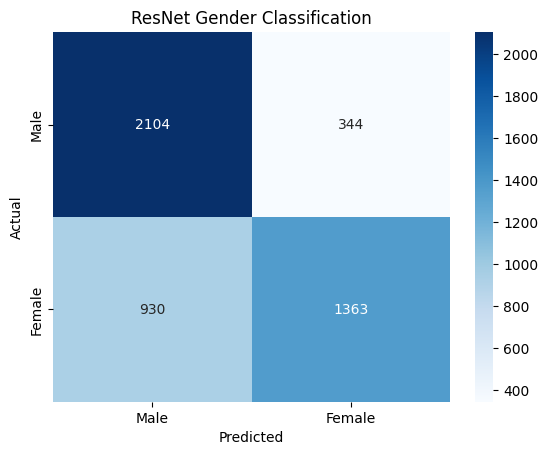

              precision    recall  f1-score   support

           0     0.6935    0.8595    0.7676      2448
           1     0.7985    0.5944    0.6815      2293

    accuracy                         0.7313      4741
   macro avg     0.7460    0.7269    0.7246      4741
weighted avg     0.7443    0.7313    0.7260      4741

Actual males predicted: 2104
Misclassified males: 344
Actual females predicted: 1363
Misclassified females: 930

Total correct predictions: 3467 / 4741
Accuracy: 0.7313


In [119]:
# Confusion matrix
y_pred_g = (gender_model.predict(X_test_g) > 0.5).astype('int32')

matrix = confusion_matrix(y_test_g, y_pred_g)
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Male','Female'], yticklabels=['Male','Female'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet Gender Classification")
plt.show()

# Detailed counts
actual_male_predicted = matrix[0][0]
misclassified_male = matrix[0][1]
actual_female_predicted = matrix[1][1]
misclassified_female = matrix[1][0]

total_correct = actual_male_predicted + actual_female_predicted
total_image = matrix.sum()

print(classification_report(y_test_g, y_pred_g, digits=4))
print(f"Actual males predicted: {actual_male_predicted}")
print(f"Misclassified males: {misclassified_male}")
print(f"Actual females predicted: {actual_female_predicted}")
print(f"Misclassified females: {misclassified_female}")
print(f"\nTotal correct predictions: {total_correct} / {total_image}")
print(f"Accuracy: {total_correct / total_image:.4f}")

149/149 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step


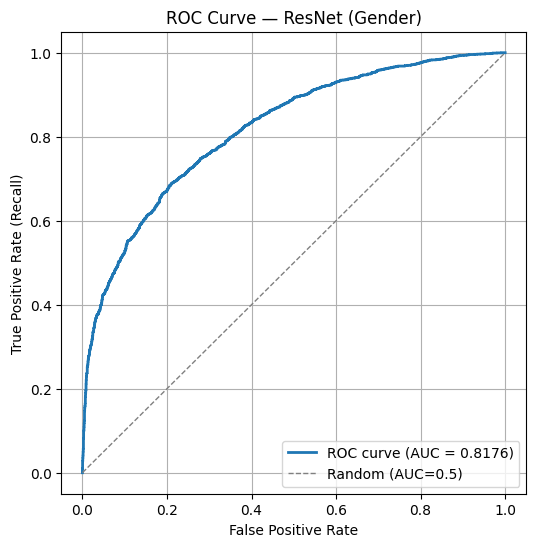

In [120]:
probs_g = gender_model.predict(X_test_g).ravel()

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test_g, probs_g)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='C0', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — ResNet (Gender)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## RestNet50 Race Classification

In [36]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_cnn, y_race, test_size=0.2, random_state=42
)

In [37]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)

base_model.trainable = False

In [38]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

race_output = Dense(5, activation='softmax')(x)

race_model = Model(inputs=base_model.input, outputs=race_output)

In [39]:
race_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
race_model.fit(
    X_train_r, y_train_r,
    validation_split=0.1,
    epochs=12,
    batch_size=32
)

Epoch 1/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 46s 85ms/step - accuracy: 0.4910 - loss: 1.2745 - val_accuracy: 0.4976 - val_loss: 1.2462
Epoch 2/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - accuracy: 0.4932 - loss: 1.2672 - val_accuracy: 0.5103 - val_loss: 1.2372
Epoch 3/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - accuracy: 0.4935 - loss: 1.2648 - val_accuracy: 0.5150 - val_loss: 1.2295
Epoch 4/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - accuracy: 0.4984 - loss: 1.2590 - val_accuracy: 0.4808 - val_loss: 1.2677
Epoch 5/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 47s 87ms/step - accuracy: 0.4987 - loss: 1.2550 - val_accuracy: 0.5256 - val_loss: 1.2185
Epoch 6/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - accuracy: 0.4965 - loss: 1.2568 - val_accuracy: 0.5219 - val_loss: 1.2156
Epoch 7/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 45s 85ms/step - accuracy: 0.5035 - loss: 1.2438 - val_accuracy: 0.5213 - val_loss: 1.2253
Epoch 8/12
534/534 ━━━━━━━━━━━━━━━━━━━━ 46s 86ms/step - accuracy: 0.5039 - loss: 1.2441 - 

In [43]:
test_loss, test_acc = gender_model.evaluate(X_test_r, y_test_r, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.3092
